In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [43]:
df=pd.read_csv(r"c:\Users\LENOVO\Downloads\mobile_payment_fraud_dataset.csv 2.csv")
df

,Transaction_ID,Amount,Time,Location,Device_Type,Transaction_Type,Account_Age
0,1,1878.96,21,Rural,Android,UPI,52
1,2,4754.06,16,Semi-Urban,iOS,UPI,36
2,3,3662.65,8,Rural,Android,Wallet,38
3,4,2997.31,0,Urban,Android,UPI,39
4,5,788.53,20,Rural,Android,Card,50
...,...,...,...,...,...,...,...
495,496,1773.23,10,Urban,Android,Card,16
496,497,2922.44,5,Semi-Urban,iOS,UPI,16
497,498,397.90,1,Rural,iOS,UPI,54
498,499,4872.23,6,Urban,Android,Card,31


In [44]:
df.head()

,Transaction_ID,Amount,Time,Location,Device_Type,Transaction_Type,Account_Age
0,1,1878.96,21,Rural,Android,UPI,52
1,2,4754.06,16,Semi-Urban,iOS,UPI,36
2,3,3662.65,8,Rural,Android,Wallet,38
3,4,2997.31,0,Urban,Android,UPI,39
4,5,788.53,20,Rural,Android,Card,50


In [31]:
df.tail()

,Transaction_ID,Amount,Time,Location,Device_Type,Transaction_Type,Account_Age
495,496,1773.23,10,Urban,Android,Card,16
496,497,2922.44,5,Semi-Urban,iOS,UPI,16
497,498,397.90,1,Rural,iOS,UPI,54
498,499,4872.23,6,Urban,Android,Card,31
499,500,4931.19,17,Rural,iOS,UPI,42


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    500 non-null    int64  
 1   Amount            500 non-null    float64
 2   Time              500 non-null    int64  
 3   Location          500 non-null    str    
 4   Device_Type       500 non-null    str    
 5   Transaction_Type  500 non-null    str    
 6   Account_Age       500 non-null    int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 27.5 KB


In [33]:
df.describe()

,Transaction_ID,Amount,Time,Account_Age
count,500.000000,500.000000,500.00000,500.000000
mean,250.500000,2497.823100,11.10800,30.760000
std,144.481833,1490.455273,7.08157,16.728481
min,1.000000,35.260000,0.00000,1.000000
25%,125.750000,1213.982500,5.00000,17.000000
50%,250.500000,2570.685000,11.00000,31.000000
75%,375.250000,3783.062500,17.00000,45.000000
max,500.000000,4964.890000,23.00000,59.000000


In [34]:
df.shape

(500, 7)

In [35]:
df.columns

Index(['Transaction_ID', 'Amount', 'Time', 'Location', 'Device_Type',
       'Transaction_Type', 'Account_Age'],
      dtype='str')

In [36]:
df.isnull().sum()

Transaction_ID      0
Amount              0
Time                0
Location            0
Device_Type         0
Transaction_Type    0
Account_Age         0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

In [47]:
df = df.ffill()

In [53]:
df.ffill(inplace=True)

,Transaction_ID,Amount,Time,Location,Device_Type,Transaction_Type,Account_Age
0,1,1878.96,21,Rural,Android,UPI,52
1,2,4754.06,16,Semi-Urban,iOS,UPI,36
2,3,3662.65,8,Rural,Android,Wallet,38
3,4,2997.31,0,Urban,Android,UPI,39
4,5,788.53,20,Rural,Android,Card,50
...,...,...,...,...,...,...,...
495,496,1773.23,10,Urban,Android,Card,16
496,497,2922.44,5,Semi-Urban,iOS,UPI,16
497,498,397.90,1,Rural,iOS,UPI,54
498,499,4872.23,6,Urban,Android,Card,31


In [56]:
df.columns = df.columns.str.strip().str.lower()

In [57]:
le = LabelEncoder()

categorical_cols = ['location', 'device_type', 'transaction_type']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [59]:
df['is_fraud'] = df['amount'].apply(lambda x: 1 if x > 5000 else 0)

In [60]:
X = df[['transaction_id', 'amount', 'time', 'location', 
        'device_type', 'transaction_type', 'account_age']]

y = df['is_fraud']   # target column

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
y_pred = model.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nFull Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Full Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

In [75]:
# Count all values
fraud_counts = df['is_fraud'].value_counts()

print(fraud_counts)

is_fraud
0    500
Name: count, dtype: int64


In [66]:
fraud_percent = df['is_fraud'].value_counts(normalize=True) * 100
print(fraud_percent)

is_fraud
0    100.0
Name: proportion, dtype: float64


In [68]:
df.columns

Index(['transaction_id', 'amount', 'time', 'location', 'device_type',
       'transaction_type', 'account_age', 'is_fraud'],
      dtype='str')

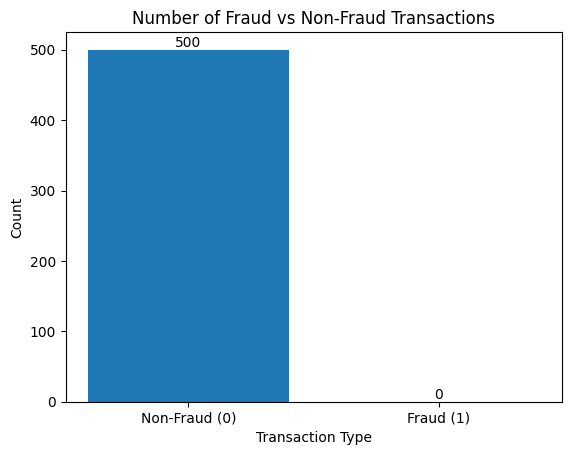

In [ ]:

# Count values (ensure both 0 and 1 are included)
fraud_counts = df['is_fraud'].value_counts().reindex([0, 1], fill_value=0)

# Plot bar chart
plt.figure()
bars = plt.bar(['Non-Fraud (0)', 'Fraud (1)'], fraud_counts)

# Titles and labels
plt.title("Number of Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.show()

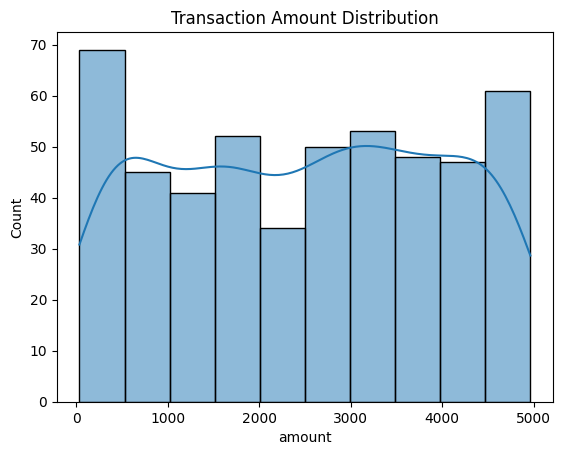

In [72]:
sns.histplot(df['amount'], kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

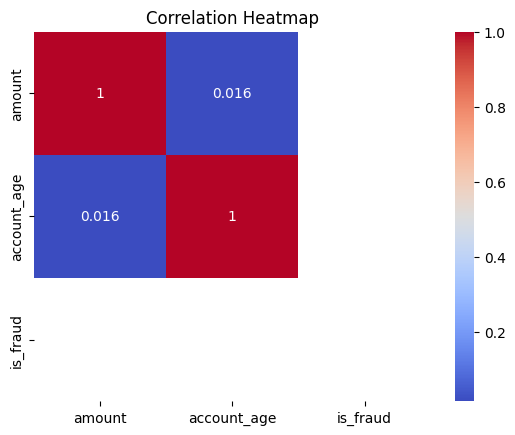

In [73]:
corr = df[['amount', 'account_age', 'is_fraud']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()